## **Sleep Disorder Prediction Model**

In [ ]:
# Import all libraries needed for data processing, modelling, and evaluation
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler,LabelEncoder
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from collections import Counter
from sklearn.base import clone
import joblib
from sklearn.model_selection import GridSearchCV


In [ ]:
# Load the dataset
df= pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/Final Project/newly created.csv")

In [ ]:
df

,Person ID,Gender,Age,Occupation,Sleep Duration (hours),Quality of Sleep (scale: 1-10),Physical Activity Level (minutes/day),Stress Level (scale: 1-10),BMI Category,Blood Pressure (systolic/diastolic),Heart Rate (bpm),Daily Steps,Sleep Disorder
0,1,Male,29,Manual Labor,7.4,7.0,41,7,Obese,124/70,91,8539,NaN
1,2,Female,43,Retired,4.2,4.9,41,5,Obese,131/86,81,18754,NaN
2,3,Male,44,Retired,6.1,6.0,107,4,Underweight,122/70,81,2857,NaN
3,4,Male,29,Office Worker,8.3,10.0,20,10,Obese,124/72,55,6886,NaN
4,5,Male,67,Retired,9.1,9.5,19,4,Overweight,133/78,97,14945,Insomnia
...,...,...,...,...,...,...,...,...,...,...,...,...,...
769,770,Female,59,Nurse,8.1,9.0,75,3,Overweight,140/95,68,7000,Sleep Apnea
770,771,Female,59,Nurse,8.0,9.0,75,3,Overweight,140/95,68,7000,Sleep Apnea
771,772,Female,59,Nurse,8.1,9.0,75,3,Overweight,140/95,68,7000,Sleep Apnea
772,773,Female,59,Nurse,8.1,9.0,75,3,Overweight,140/95,68,7000,Sleep Apnea


**Data Cleaning & Preprocessing**

In [ ]:
# Checking for missing values
df.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration (hours),0
Quality of Sleep (scale: 1-10),0
Physical Activity Level (minutes/day),0
Stress Level (scale: 1-10),0
BMI Category,0
Blood Pressure (systolic/diastolic),0


In [ ]:
# Replace missing values in 'Sleep Disorder' with 'None'
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

df['Sleep Disorder'] = df['Sleep Disorder'].str.strip().str.title()

In [ ]:
# Check for duplicates
print("Rows:", df.shape[0])
print("Duplicates:", df.duplicated().sum())

Rows: 774
Duplicates: 0


In [ ]:
# Check data types of columns
df.dtypes

,0
Person ID,int64
Gender,object
Age,int64
Occupation,object
Sleep Duration (hours),float64
Quality of Sleep (scale: 1-10),float64
Physical Activity Level (minutes/day),int64
Stress Level (scale: 1-10),int64
BMI Category,object
Blood Pressure (systolic/diastolic),object


In [ ]:
# Correcting the inconsistency in 'BMI Category'
df['BMI Category'] = df['BMI Category'].replace({'Normal Weight': 'Normal'})

In [ ]:
# Split Blood Pressure into two columns Systolic and Diastolic
df[['Systolic', 'Diastolic']] = df['Blood Pressure (systolic/diastolic)'].str.split('/', expand=True)

df['Systolic'] = df['Systolic'].astype(int)
df['Diastolic'] = df['Diastolic'].astype(int)

In [ ]:
# Remove Person ID and Blood Pressure columns
df = df.copy()

df = df.drop(['Person ID', 'Blood Pressure (systolic/diastolic)'], axis=1)

In [ ]:
#Standardize whitespace/casing on text columns to avoid accidental categories
for col in ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']:
    df[col] = df[col].astype('string').str.strip().str.title()

In [ ]:
df.dtypes

,0
Gender,string[python]
Age,int64
Occupation,string[python]
Sleep Duration (hours),float64
Quality of Sleep (scale: 1-10),float64
Physical Activity Level (minutes/day),int64
Stress Level (scale: 1-10),int64
BMI Category,string[python]
Heart Rate (bpm),int64
Daily Steps,int64


In [ ]:
# Detect and print outliers without removing them
num_cols = [
    'Age', 'Sleep Duration (hours)', 'Quality of Sleep (scale: 1-10)', 'Physical Activity Level (minutes/day)',
    'Stress Level (scale: 1-10)', 'Systolic', 'Diastolic','Heart Rate (bpm)','Daily Steps'
]

df_for_outliers = df.copy()

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")
    if len(outliers) > 0:
        print(outliers[[col]])

Age: 3 outliers
     Age
27    80
57    90
326   86
Sleep Duration (hours): 3 outliers
     Sleep Duration (hours)
130                    12.0
180                    12.0
285                    12.0
Quality of Sleep (scale: 1-10): 19 outliers
     Quality of Sleep (scale: 1-10)
11                              2.7
27                              2.8
41                              1.0
43                              2.5
77                              2.0
81                              1.0
131                             1.7
140                             1.0
143                             2.7
156                             2.6
174                             2.8
232                             2.0
266                             2.3
269                             1.7
305                             2.0
326                             1.0
331                             2.4
335                             1.0
353                             2.8
Physical Activity Level (minutes/day)

Outliers were not removed because the web-based sleep disorder prediction application is intended for use by the general population, where valid extreme values (e.g., older ages or longer sleep durations) may naturally occur. Retaining these values helps preserve real-world variability and improves the model’s applicability to diverse users.

In [ ]:
# Get min and max for each column
columns_of_interest = [
    'Age',
    'Sleep Duration (hours)',
    'Quality of Sleep (scale: 1-10)',
    'Physical Activity Level (minutes/day)',
    'Stress Level (scale: 1-10)',
    'Systolic',
    'Diastolic',
    'Heart Rate (bpm)',
    'Daily Steps'
]
min_max_values = df[columns_of_interest].agg(['min', 'max'])

print(min_max_values)

     Age  Sleep Duration (hours)  Quality of Sleep (scale: 1-10)  \
min   18                     4.1                             1.0   
max   90                    12.0                            10.0   

     Physical Activity Level (minutes/day)  Stress Level (scale: 1-10)  \
min                                     10                           1   
max                                    120                          10   

     Systolic  Diastolic  Heart Rate (bpm)  Daily Steps  
min       109         60                50         2067  
max       145         96               100        19958  


In [ ]:
# Check value counts for categorical columns
categorical_cols = ['Gender', 'BMI Category', 'Sleep Disorder', 'Occupation']

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Gender
Gender
Male      388
Female    386
Name: count, dtype: Int64

BMI Category
BMI Category
Normal         307
Overweight     257
Obese          108
Underweight    102
Name: count, dtype: Int64

Sleep Disorder
Sleep Disorder
None           509
Insomnia       156
Sleep Apnea    109
Name: count, dtype: Int64

Occupation
Occupation
Student                 110
Office Worker            99
Manual Labor             96
Retired                  95
Nurse                    73
Doctor                   71
Engineer                 63
Lawyer                   47
Teacher                  40
Accountant               37
Salesperson              32
Scientist                 4
Software Engineer         4
Sales Representative      2
Manager                   1
Name: count, dtype: Int64


In [ ]:
# Sleep Disorder Percentage
sleep_disorder_percentage = (
    df['Sleep Disorder']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(sleep_disorder_percentage)


Sleep Disorder
None           65.76
Insomnia       20.16
Sleep Apnea    14.08
Name: proportion, dtype: Float64


**Data Visualization & EDA**

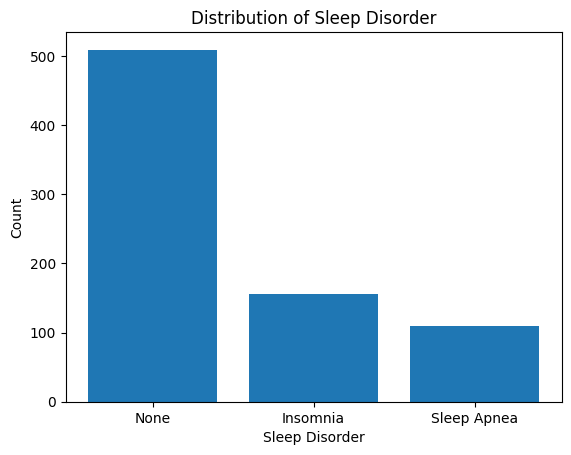

In [ ]:
# Bar chart
sleep_counts = df['Sleep Disorder'].value_counts()

plt.figure()
plt.bar(sleep_counts.index, sleep_counts.values)
plt.title('Distribution of Sleep Disorder')
plt.xlabel('Sleep Disorder')
plt.ylabel('Count')
plt.show()

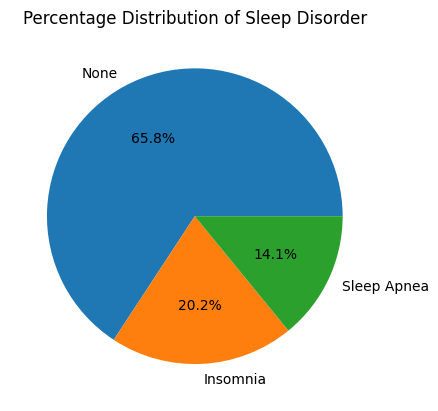

In [ ]:
#Pie chart
plt.figure()
plt.pie(
    sleep_counts.values,
    labels=sleep_counts.index,
    autopct='%1.1f%%'
)
plt.title('Percentage Distribution of Sleep Disorder')
plt.show()


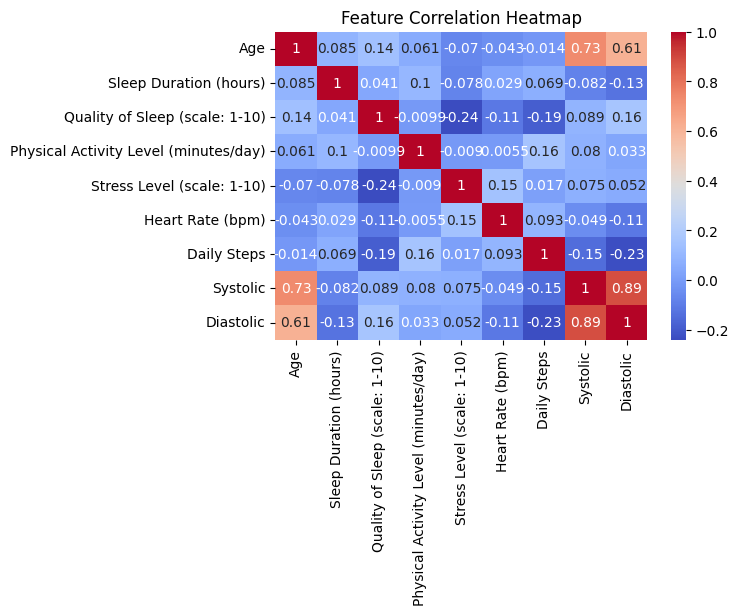

In [ ]:
# Correlation heatmap (numeric features)
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

**Model Preparation**

In [ ]:
#split the target and features
target_col = "Sleep Disorder"

X = df.drop(columns=[target_col])
y = df[target_col]

print("Feature columns:",list(X.columns))
print("Target distribution:")
print(y.value_counts())

Feature columns: ['Gender', 'Age', 'Occupation', 'Sleep Duration (hours)', 'Quality of Sleep (scale: 1-10)', 'Physical Activity Level (minutes/day)', 'Stress Level (scale: 1-10)', 'BMI Category', 'Heart Rate (bpm)', 'Daily Steps', 'Systolic', 'Diastolic']
Target distribution:
Sleep Disorder
None           509
Insomnia       156
Sleep Apnea    109
Name: count, dtype: Int64


In [ ]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (619, 12)
Test set size: (155, 12)


In [ ]:
# Encode the string target labels (None, Insomnia, Sleep Apnea) into integers (1, 0, 2)
label_enc = LabelEncoder()

y_train = label_enc.fit_transform(y_train)
y_test = label_enc.transform(y_test)

print("Target mapping:")
print(dict(zip(label_enc.classes_, label_enc.transform(label_enc.classes_))))


Target mapping:
{'Insomnia': np.int64(0), 'None': np.int64(1), 'Sleep Apnea': np.int64(2)}


In [ ]:
# scale numeric features, ordinal-encode BMI, one-hot encode Gender and Occupation
numeric_cols = [
    'Age',
    'Sleep Duration (hours)',
    'Quality of Sleep (scale: 1-10)',
    'Physical Activity Level (minutes/day)',
    'Stress Level (scale: 1-10)',
    'Systolic',
    'Diastolic',
    'Heart Rate (bpm)',
    'Daily Steps'
]

ordinal_cols = ['BMI Category']
ordinal_categories = [['Underweight', 'Normal', 'Overweight', 'Obese']]

categorical_cols = ['Gender', 'Occupation']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('ord', OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

**Model Training & Comparison**

In [ ]:
# Define all candidate models to compare: RandomForest, GradientBoosting, LogisticRegression, and XGBoost
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=150,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=1,
        random_state=42,
        class_weight='balanced'
    ),

    "GradientBoosting": GradientBoostingClassifier(random_state=42),

    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
"XGBoost": XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
)


}


In [ ]:
# SMOTE Visualization (ONLY for analysis)
preprocessor_temp = clone(preprocessor)
X_train_processed = preprocessor_temp.fit_transform(X_train)

smote = SMOTE(random_state=42, k_neighbors=3)
X_resampled_vis, y_resampled_vis = smote.fit_resample(X_train_processed, y_train)

print("Class distribution BEFORE SMOTE:")
print(Counter(y_train))

print("\nClass distribution AFTER SMOTE:")
print(Counter(y_resampled_vis))

Class distribution BEFORE SMOTE:
Counter({np.int64(1): 407, np.int64(0): 125, np.int64(2): 87})

Class distribution AFTER SMOTE:
Counter({np.int64(0): 407, np.int64(1): 407, np.int64(2): 407})


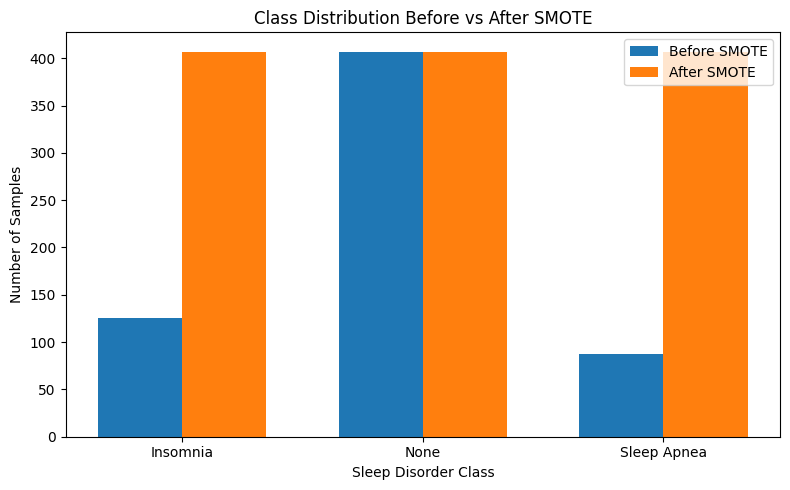

In [ ]:
# Bar Graph for class distribution before and after SMOTE count
before_counts = Counter(y_train)
after_counts = Counter(y_resampled_vis)


class_labels = label_enc.classes_


classes = range(len(class_labels))

before_values = [before_counts[c] for c in classes]
after_values = [after_counts[c] for c in classes]

x = np.arange(len(class_labels))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, before_values, width, label="Before SMOTE")
plt.bar(x + width/2, after_values, width, label="After SMOTE")

plt.xticks(x, class_labels)

plt.xlabel("Sleep Disorder Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution Before vs After SMOTE")

plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
# Train each model in a SMOTE pipeline, evaluate on the test set, and track the best model by macro F1 score
results = {}
best_model_name = None
best_f1 = 0
best_pipeline = None

for name, model in models.items():

    pipeline = ImbPipeline(steps=[
        ('preprocessing', clone(preprocessor)),
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('model', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    results[name] = (acc, f1)

    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1:.4f}")
    print(classification_report(y_test, y_pred))

    # Select best model
    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name
        best_pipeline = pipeline


RandomForest
Accuracy: 0.7871
Macro F1: 0.6913
              precision    recall  f1-score   support

           0       0.75      0.48      0.59        31
           1       0.79      0.94      0.86       102
           2       0.85      0.50      0.63        22

    accuracy                           0.79       155
   macro avg       0.79      0.64      0.69       155
weighted avg       0.79      0.79      0.77       155


GradientBoosting
Accuracy: 0.7677
Macro F1: 0.6798
              precision    recall  f1-score   support

           0       0.61      0.61      0.61        31
           1       0.82      0.87      0.85       102
           2       0.69      0.50      0.58        22

    accuracy                           0.77       155
   macro avg       0.71      0.66      0.68       155
weighted avg       0.76      0.77      0.76       155


LogisticRegression
Accuracy: 0.6903
Macro F1: 0.6228
              precision    recall  f1-score   support

           0       0.44      

**Hyperparameter Tuning**

In [ ]:
# XGBoost was chosen for tuning based on comparison results
xgb_pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('model', XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42,

    ))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

grid = GridSearchCV(
    xgb_pipeline,
    param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 200, 'model__subsample': 1.0}
Best CV Score: 0.71431277344551


**Model Evaluation**

In [ ]:
# Evaluate the best tuned XGBoost pipeline on the held-out test set and print the final classification report
best_pipeline = grid.best_estimator_

y_pred = best_pipeline.predict(X_test)

print("FINAL MODEL (Tuned XGBoost)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print(classification_report(y_test, y_pred))

FINAL MODEL (Tuned XGBoost)
Accuracy: 0.8064516129032258
Macro F1: 0.7200072621641249
              precision    recall  f1-score   support

           0       0.66      0.61      0.63        31
           1       0.83      0.93      0.88       102
           2       0.92      0.50      0.65        22

    accuracy                           0.81       155
   macro avg       0.80      0.68      0.72       155
weighted avg       0.81      0.81      0.80       155



**Feature Importance**

                                  feature  importance
18               Occupation_Office Worker    0.101490
15                      Occupation_Lawyer    0.096473
5                                Systolic    0.096442
21                 Occupation_Salesperson    0.071452
25                     Occupation_Teacher    0.071244
6                               Diastolic    0.069188
17                       Occupation_Nurse    0.052820
13                      Occupation_Doctor    0.043561
19                     Occupation_Retired    0.043496
24                     Occupation_Student    0.041097
9                            BMI Category    0.036342
8                             Daily Steps    0.035438
14                    Occupation_Engineer    0.032404
3   Physical Activity Level (minutes/day)    0.030920
16                Occupation_Manual Labor    0.027571
20        Occupation_Sales Representative    0.022531
0                                     Age    0.022299
2          Quality of Sleep 

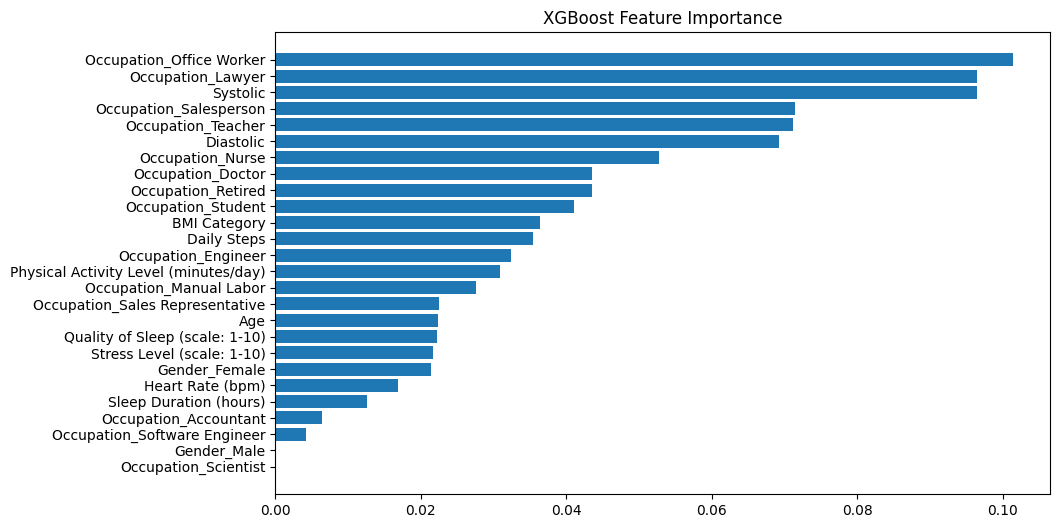

In [ ]:
# Extract and plot XGBoost feature importances to understand which features drive predictions most
xgb_model = best_pipeline.named_steps['model']


preprocessor_features = []

for name, transformer, cols in best_pipeline.named_steps['preprocessing'].transformers_:
    if name != 'remainder':
        if hasattr(transformer, 'get_feature_names_out'):
            preprocessor_features.extend(transformer.get_feature_names_out(cols))
        else:
            preprocessor_features.extend(cols)


feature_importance = pd.DataFrame({
    'feature': preprocessor_features,
    'importance': xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importance)

plt.figure(figsize=(10,6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.show()

**Save Final Model**

In [ ]:
model_package = {
    "model_name": "Tuned XGBoost",
    "pipeline": best_pipeline,
    "label_encoder": label_enc
}

joblib.dump(
    model_package,
    "/content/drive/MyDrive/Colab Notebooks/Final Project/best_sleep_model.pkl"
)

print("\n Best Model Selected: Tuned XGBoost")
print(" Model + Encoder saved successfully!")


 Best Model Selected: Tuned XGBoost
 Model + Encoder saved successfully!
